# Surface Water Fraction Model Training

This notebook is organized as an end-to-end workflow: setup, scaling study, feature-set study, explainability, optimization, and temporal/geographic evaluation.

## 1. Initial Setup

Load libraries, define reusable utilities, and prepare base model configuration.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xarray as xr
import xgboost as xgb

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
TARGET_COL = "fwns"
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
np.random.seed(RANDOM_STATE)

In [2]:
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}
    iterator = models.items() if isinstance(models, dict) else models

    for name, model in iterator:
        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results_all[name] = {
            "MAE_train": mean_absolute_error(y_train, y_pred_train),
            "MSE_train": mean_squared_error(y_train, y_pred_train),
            "R2_train": r2_score(y_train, y_pred_train),
            "MAE_test": mean_absolute_error(y_test, y_pred_test),
            "MSE_test": mean_squared_error(y_test, y_pred_test),
            "R2_test": r2_score(y_test, y_pred_test),
            "time_s": round(elapsed_time, 4),
        }

    return results_all


def format_results_table(results_dict):
    return pd.DataFrame(results_dict).T.round(6)


def preprocess_dataset(df_in, target_col=TARGET_COL, remove_zeros=False, boxcox_target=False, scale_features=False):
    df_out = df_in.copy()
    boxcox_lambda = None

    if remove_zeros:
        df_out = df_out[df_out[target_col] != 0].copy()

    if boxcox_target:
        if (df_out[target_col] <= 0).any():
            raise ValueError("Box-Cox requires strictly positive target values.")
        df_out[target_col], boxcox_lambda = stats.boxcox(df_out[target_col])

    if scale_features:
        feature_cols = df_out.columns.drop(target_col)
        scaler = StandardScaler()
        df_out[feature_cols] = scaler.fit_transform(df_out[feature_cols])

    return df_out, boxcox_lambda


def evaluate_scaling_variants(df_raw, variants, models, target_col=TARGET_COL):
    rows = []

    for variant_name, params in variants.items():
        df_variant, lam = preprocess_dataset(df_raw, target_col=target_col, **params)
        y_variant = df_variant[target_col]

        tr_idx, te_idx = train_test_split(
            df_variant.index,
            test_size=0.2,
            random_state=RANDOM_STATE,
            shuffle=True,
        )

        X_train = df_variant.drop(columns=[target_col]).loc[tr_idx]
        X_test = df_variant.drop(columns=[target_col]).loc[te_idx]
        y_train = y_variant.loc[tr_idx]
        y_test = y_variant.loc[te_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            row = {
                "variant": variant_name,
                "model": model_name,
                "rows": len(df_variant),
                "boxcox_lambda": np.nan if lam is None else lam,
                **values,
            }
            rows.append(row)

    return pd.DataFrame(rows)


def evaluate_feature_sets(df_model, y, train_idx, test_idx, feature_sets, models):
    all_rows = []

    for set_name, features in feature_sets.items():
        X_train = df_model.loc[train_idx, features]
        X_test = df_model.loc[test_idx, features]
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]

        metrics = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)

        for model_name, values in metrics.items():
            all_rows.append({
                "feature_set": set_name,
                "n_features": len(features),
                "model": model_name,
                **values,
            })

    return pd.DataFrame(all_rows)


def compute_shap_importance(xgb_model, X_test, sample_size=2000, top_n=20):
    n = min(sample_size, len(X_test))
    X_small = X_test.sample(n=n, random_state=RANDOM_STATE)
    dtest = xgb.DMatrix(X_small)
    booster = xgb_model.get_booster()
    shap_values = booster.predict(dtest, pred_contribs=True)

    shap_values_features = shap_values[:, :-1]
    mean_abs_shap = np.abs(shap_values_features).mean(axis=0)

    importance_df = pd.DataFrame({
        "feature": X_small.columns,
        "importance": mean_abs_shap,
    }).sort_values("importance", ascending=False)

    return importance_df.head(top_n), X_small


def create_temporal_split(df_in, day_col="day", test_size=0.27):
    unique_days = np.sort(df_in[day_col].unique())
    split_idx = int(len(unique_days) * (1 - test_size))
    train_days = unique_days[:split_idx]
    test_days = unique_days[split_idx:]
    return df_in.index[df_in[day_col].isin(train_days)], df_in.index[df_in[day_col].isin(test_days)]


def create_geographic_corner_split(df_in, lat_col="latitude_grid", lon_col="longitude_grid", target_test_size=0.19):
    q = 1 - np.sqrt(target_test_size)
    lat_cut = df_in[lat_col].quantile(q)
    lon_cut = df_in[lon_col].quantile(q)
    test_mask = (df_in[lat_col] >= lat_cut) & (df_in[lon_col] >= lon_cut)
    return df_in.index[~test_mask], df_in.index[test_mask]


def create_geographic_block_split(df_in, lat_col="latitude_grid", lon_col="longitude_grid", n_bins=6, test_frac=0.21):
    temp = df_in[[lat_col, lon_col]].copy()
    lat_bins = np.linspace(temp[lat_col].min(), temp[lat_col].max(), n_bins)
    lon_bins = np.linspace(temp[lon_col].min(), temp[lon_col].max(), n_bins)

    temp["lat_block"] = np.digitize(temp[lat_col], lat_bins)
    temp["lon_block"] = np.digitize(temp[lon_col], lon_bins)
    temp["geo_block"] = temp["lat_block"].astype(str) + "_" + temp["lon_block"].astype(str)

    unique_blocks = temp["geo_block"].unique()
    np.random.seed(RANDOM_STATE)
    np.random.shuffle(unique_blocks)

    n_test_blocks = max(1, int(test_frac * len(unique_blocks)))
    test_blocks = set(unique_blocks[:n_test_blocks])

    test_mask = temp["geo_block"].isin(test_blocks)
    return temp.index[~test_mask], temp.index[test_mask]

### 1.1 Data Loading and Baseline Split

Load merged data and create the baseline train/test split used for the feature-set and downstream studies.

In [3]:
df_raw = pd.read_parquet("data/windsat_2017")
print(f"Loaded rows: {len(df_raw):,}")
print(f"Loaded columns: {len(df_raw.columns)}")
display(df_raw.head(2))

Loaded rows: 13,225,757
Loaded columns: 48


,latitude_grid,longitude_grid,surtep_ERA5,fwns,Tmn,PWV,VOD,vsm,VPD,ref_land_emis_de_lannoy_K_h,...,emiss37V_de_lannoy,denominator,term_1,term_2,fwns_calculated,clase,porcentaje clase,sm_bin,vod_bin,day
0,-55.375,290.375,281.021973,0.428428,276.725922,18.756065,0.212244,0.5,0.101363,0.825967,...,0.714926,1.605275,1.325904,0.819594,0.506310,6.0,22.0,-1,4,1
1,-55.375,290.625,280.897614,0.428428,276.725922,18.756065,0.212244,0.5,0.101363,0.825967,...,0.744006,1.605275,1.325904,0.870613,0.455292,25.0,45.0,-1,4,1


In [4]:
BASE_PREPROCESSING = {
    "remove_zeros": True,
    "boxcox_target": True,
    "scale_features": True,
}

df_model, fwns_lambda = preprocess_dataset(df_raw, **BASE_PREPROCESSING)
y = df_model[TARGET_COL]

train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

models = {
    "LinearRegression": LinearRegression(),
    "XGBoost": XGBRegressor(
        n_estimators=20,
        learning_rate=0.1,
        max_depth=15,
        verbosity=0,
        random_state=RANDOM_STATE,
        device="gpu",
    ),
}

print(f"Modeling rows: {len(df_model):,}")
print(f"Box-Cox lambda: {fwns_lambda:.6f}")

Modeling rows: 8,965,273
Box-Cox lambda: 0.139383


## 2. Scaling Study

Study whether feature scaling and target scaling improve predictive performance.

In [5]:
SCALING_VARIANTS = {
    "raw": {"remove_zeros": False, "boxcox_target": False, "scale_features": False},
    "scaled_features": {"remove_zeros": False, "boxcox_target": False, "scale_features": True},
    "remove_zeros": {"remove_zeros": True, "boxcox_target": False, "scale_features": False},
    "remove_zeros_scaled": {"remove_zeros": True, "boxcox_target": False, "scale_features": True},
    "boxcox_target": {"remove_zeros": True, "boxcox_target": True, "scale_features": False},
    "full_scale": {"remove_zeros": True, "boxcox_target": True, "scale_features": True},
}

In [6]:
scaling_results = evaluate_scaling_variants(df_raw, SCALING_VARIANTS, models, target_col=TARGET_COL)
scaling_view = scaling_results.sort_values(["model", "R2_test"], ascending=[True, False])
display(scaling_view)

best_scaling_xgb = scaling_view[scaling_view["model"] == "XGBoost"].iloc[0]
print("Selected scaling strategy for downstream sections:")
print(best_scaling_xgb[["variant", "R2_test", "MAE_test", "MSE_test"]])

,variant,model,rows,boxcox_lambda,MAE_train,MSE_train,R2_train,MAE_test,MSE_test,R2_test,time_s
0,raw,LinearRegression,13225757,NaN,0.016981,0.000737,0.864628,0.017008,0.000743,0.863913,9.2086
2,scaled_features,LinearRegression,13225757,NaN,0.016981,0.000737,0.864628,0.017008,0.000743,0.863913,8.5558
4,remove_zeros,LinearRegression,8965273,NaN,0.020008,0.000949,0.860923,0.019991,0.000948,0.860731,5.5547
6,remove_zeros_scaled,LinearRegression,8965273,NaN,0.020008,0.000949,0.860923,0.019991,0.000948,0.860731,5.5060
8,boxcox_target,LinearRegression,8965273,0.139383,0.319404,0.182624,0.740514,0.319745,0.182844,0.740536,5.4110
10,full_scale,LinearRegression,8965273,0.139383,0.319404,0.182624,0.740514,0.319745,0.182844,0.740536,5.2174
3,scaled_features,XGBoost,13225757,NaN,0.012108,0.000389,0.928476,0.012497,0.000434,0.920537,20.6092
1,raw,XGBoost,13225757,NaN,0.012139,0.000390,0.928330,0.012527,0.000435,0.920371,20.9110
5,remove_zeros,XGBoost,8965273,NaN,0.015027,0.000533,0.921890,0.015588,0.000597,0.912276,17.7681
7,remove_zeros_scaled,XGBoost,8965273,NaN,0.015073,0.000537,0.921365,0.015629,0.000600,0.911781,17.6161


Selected scaling strategy for downstream sections:
variant     scaled_features
R2_test            0.920537
MAE_test           0.012497
MSE_test           0.000434
Name: 3, dtype: object


## 3. Feature-Set Accuracy Study

Compare 18 feature sets, grouped by design motivation (baseline, atmospheric correction, LUT information, extra channels, engineered features, auxiliary variables, and geospatial context).

In [7]:
FEATURE_SETS = {
    "set_1": ["tbtoa19H"],
    "set_2": ["tbtoa19H", "surtep_ERA5"],
    "set_3": ["tbboa_de_lannoy19H", "surtep_ERA5"],
    "set_4": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "surtep_ERA5"],
    "set_5": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbboa_1st_order19H", "tbboa_de_lannoy19H", "surtep_ERA5"],
    "set_6": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "surtep_ERA5", "vsm", "VOD"],
    "set_7": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "surtep_ERA5", "ref_land_emis_de_lannoy_K_h", "ref_land_emis_de_lannoy_K_v"],
    "set_8": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "surtep_ERA5", "vsm", "VOD", "ref_land_emis_de_lannoy_K_h", "ref_land_emis_de_lannoy_K_v"],
    "set_9": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "surtep_ERA5", "vsm", "VOD"],
    "set_10": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD"],
    "set_11": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "emiss19H_de_lannoy", "emiss19V_de_lannoy", "emiss37H_de_lannoy", "emiss37V_de_lannoy"],
    "set_12": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "emiss19H_de_lannoy", "emiss19V_de_lannoy", "emiss37H_de_lannoy", "emiss37V_de_lannoy", "denominator", "term_1", "term_2", "fwns_calculated"],
    "set_13": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "clase"],
    "set_14": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "Tmn", "PWV", "VPD"],
    "set_15": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "clase", "Tmn", "PWV", "VPD"],
    "set_16": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "Tmn", "PWV", "VPD", "latitude_grid"],
    "set_17": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "Tmn", "PWV", "VPD", "longitude_grid"],
    "set_18": ["tbtoa19H", "tran19H", "tbup19H", "tbdw19H", "tbtoa37H", "tran37H", "tbup37H", "tbdw37H", "tbtoa19V", "tran19V", "tbup19V", "tbdw19V", "tbtoa37V", "tran37V", "tbup37V", "tbdw37V", "surtep_ERA5", "vsm", "VOD", "Tmn", "PWV", "VPD", "latitude_grid", "longitude_grid"],
}

In [8]:
feature_results = evaluate_feature_sets(df_model, y, train_idx, test_idx, FEATURE_SETS, models)
feature_ranking = feature_results.sort_values(["model", "R2_test"], ascending=[True, False]).reset_index(drop=True)
display(feature_ranking)

best_feature_row = feature_ranking[feature_ranking["model"] == "XGBoost"].iloc[0]
best_feature_set_name = best_feature_row["feature_set"]
best_feature_set = FEATURE_SETS[best_feature_set_name]

print("Selected feature set for downstream analyses:")
print(best_feature_row[["feature_set", "n_features", "R2_test", "MAE_test", "MSE_test"]])

X_selected_train = df_model.loc[train_idx, best_feature_set]
X_selected_test = df_model.loc[test_idx, best_feature_set]
y_selected_train = y.loc[train_idx]
y_selected_test = y.loc[test_idx]

,feature_set,n_features,model,MAE_train,MSE_train,R2_train,MAE_test,MSE_test,R2_test,time_s
0,set_12,27,LinearRegression,0.342872,0.206570,0.706491,0.343246,0.206838,0.706488,3.3236
1,set_18,24,LinearRegression,0.346578,0.210338,0.701136,0.347072,0.210879,0.700754,2.7860
2,set_16,23,LinearRegression,0.349589,0.212823,0.697605,0.350107,0.213326,0.697280,2.6206
3,set_17,23,LinearRegression,0.350005,0.213379,0.696815,0.350554,0.213954,0.696390,2.6826
4,set_15,23,LinearRegression,0.352018,0.215018,0.694487,0.352564,0.215564,0.694104,2.6709
5,set_14,22,LinearRegression,0.352121,0.215083,0.694395,0.352666,0.215624,0.694019,2.5641
6,set_11,23,LinearRegression,0.356011,0.219701,0.687833,0.356428,0.220072,0.687707,2.7237
7,set_13,20,LinearRegression,0.359881,0.223953,0.681791,0.360348,0.224415,0.681545,2.4755
8,set_10,19,LinearRegression,0.359970,0.224013,0.681706,0.360437,0.224474,0.681462,2.2770
9,set_8,9,LinearRegression,0.373357,0.237430,0.662642,0.373794,0.237894,0.662417,0.8257


Selected feature set for downstream analyses:
feature_set      set_18
n_features           24
R2_test        0.815617
MAE_test       0.258352
MSE_test       0.129935
Name: 18, dtype: object


In [9]:
if "fwns_calculated" in df_model.columns:
    baseline_mae = mean_absolute_error(y, df_model["fwns_calculated"])
    baseline_mse = mean_squared_error(y, df_model["fwns_calculated"])
    baseline_r2 = r2_score(y, df_model["fwns_calculated"])
    print("Physics baseline metrics (fwns_calculated):")
    print({"MAE": baseline_mae, "MSE": baseline_mse, "R2": baseline_r2})
else:
    print("Column fwns_calculated not available in this dataset.")

Physics baseline metrics (fwns_calculated):
{'MAE': 2.7412047932020367, 'MSE': 7.960280243402038, 'R2': -10.307639905235112}


## 4. Explainability Study

Train an XGBoost model on the selected feature set and inspect global SHAP importance.

,feature,importance
0,tbtoa19H,0.252943
20,PWV,0.120677
16,surtep_ERA5,0.113384
17,vsm,0.111170
8,tbtoa19V,0.090770
4,tbtoa37H,0.084949
12,tbtoa37V,0.070795
19,Tmn,0.069395
18,VOD,0.042243
1,tran19H,0.021816


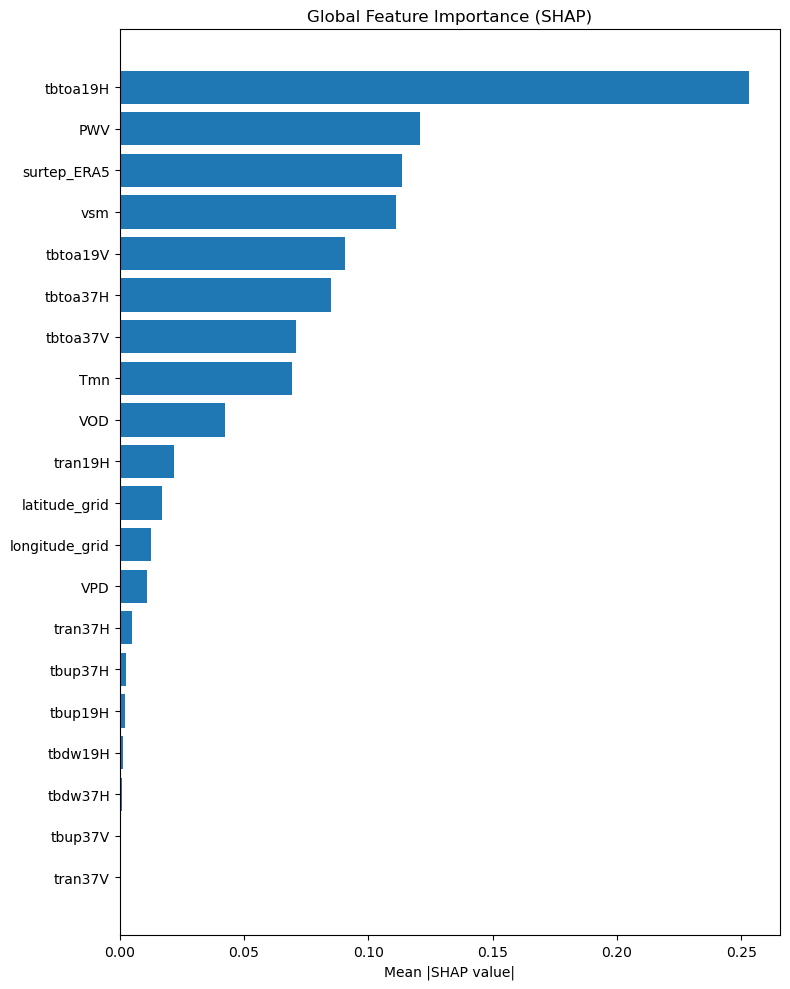

In [10]:
xgb_explained = XGBRegressor(
    n_estimators=20,
    learning_rate=0.1,
    max_depth=15,
    verbosity=0,
    random_state=RANDOM_STATE,
    device="gpu",
)
xgb_explained.fit(X_selected_train, y_selected_train)

importance_df, X_shap = compute_shap_importance(xgb_explained, X_selected_test, sample_size=2000, top_n=20)
display(importance_df)

plt.figure(figsize=(8, 10))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

## 5. Optimization Procedure

Optimize XGBoost hyperparameters with Optuna using the selected feature set and report final cross-validated RMSE.

In [11]:
N_TRIALS = 100
EARLY_STOPPING_ROUNDS = 50
N_SPLITS_TUNING = 3
N_SPLITS_FINAL = 5
TUNING_SAMPLE_FRAC = 0.7

if TUNING_SAMPLE_FRAC < 1.0:
    X_tune = X_selected_train.sample(frac=TUNING_SAMPLE_FRAC, random_state=RANDOM_STATE)
    y_tune = y_selected_train.loc[X_tune.index]
else:
    X_tune = X_selected_train
    y_tune = y_selected_train

kf_tuning = KFold(n_splits=N_SPLITS_TUNING, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "device": "cuda",
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 10, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-6, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "random_state": RANDOM_STATE,
    }

    rmse_scores = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf_tuning.split(X_tune)):
        X_train_fold = X_tune.iloc[tr_idx]
        y_train_fold = y_tune.iloc[tr_idx]
        X_valid_fold = X_tune.iloc[va_idx]
        y_valid_fold = y_tune.iloc[va_idx]

        dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
        dvalid = xgb.DMatrix(X_valid_fold, label=y_valid_fold)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=2000,
            evals=[(dvalid, "valid")],
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbose_eval=False,
        )

        preds = model.predict(dvalid)
        rmse = root_mean_squared_error(y_valid_fold, preds)
        rmse_scores.append(rmse)

        trial.report(np.mean(rmse_scores), fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(rmse_scores)

In [ ]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.SuccessiveHalvingPruner(),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_xgb_params = {
    **best_params,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_STATE,
}

kf_final = KFold(n_splits=N_SPLITS_FINAL, shuffle=True, random_state=RANDOM_STATE)
final_rmse_scores = []

for tr_idx, va_idx in kf_final.split(X_selected_train):
    X_train_fold = X_selected_train.iloc[tr_idx]
    y_train_fold = y_selected_train.iloc[tr_idx]
    X_valid_fold = X_selected_train.iloc[va_idx]
    y_valid_fold = y_selected_train.iloc[va_idx]

    dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
    dvalid = xgb.DMatrix(X_valid_fold, label=y_valid_fold)

    tuned_model = xgb.train(
        best_xgb_params,
        dtrain,
        num_boost_round=2000,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose_eval=False,
    )

    preds = tuned_model.predict(dvalid)
    final_rmse_scores.append(root_mean_squared_error(y_valid_fold, preds))

print(f"Best RMSE (Optuna): {study.best_value:.6f}")
print(f"Final {N_SPLITS_FINAL}-fold RMSE: {np.mean(final_rmse_scores):.6f}")
print(best_xgb_params)

with open("best_xgb_params.json", "w", encoding="utf-8") as f:
    json.dump(best_xgb_params, f, indent=4)

## 6. Temporal and Geographic Training

Evaluate the selected feature/model setup under non-random splits to test temporal and spatial generalization.

In [12]:
train_idx_time, test_idx_time = create_temporal_split(df_model, day_col="day", test_size=0.27)
train_idx_geo_corner, test_idx_geo_corner = create_geographic_corner_split(df_model, target_test_size=0.19)
train_idx_geo_block, test_idx_geo_block = create_geographic_block_split(df_model, n_bins=6, test_frac=0.21)

def evaluate_named_split(split_name, tr_idx, te_idx):
    X_train = df_model.loc[tr_idx, best_feature_set]
    X_test = df_model.loc[te_idx, best_feature_set]
    y_train = y.loc[tr_idx]
    y_test = y.loc[te_idx]

    split_results = train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models)
    split_table = format_results_table(split_results).reset_index().rename(columns={"index": "model"})
    split_table.insert(0, "split", split_name)
    return split_table

temporal_table = evaluate_named_split("temporal", train_idx_time, test_idx_time)
geo_corner_table = evaluate_named_split("geographic_corner", train_idx_geo_corner, test_idx_geo_corner)
geo_block_table = evaluate_named_split("geographic_block", train_idx_geo_block, test_idx_geo_block)

final_split_comparison = pd.concat([temporal_table, geo_corner_table, geo_block_table], ignore_index=True)
display(final_split_comparison)

,split,model,MAE_train,MSE_train,R2_train,MAE_test,MSE_test,R2_test,time_s
0,temporal,LinearRegression,0.341820,0.205596,0.708288,0.370548,0.234973,0.662470,2.8562
1,temporal,XGBoost,0.247231,0.119523,0.830413,0.286512,0.156713,0.774888,14.6045
2,geographic_corner,LinearRegression,0.357280,0.220769,0.672875,0.356694,0.194034,0.725558,2.7315
3,geographic_corner,XGBoost,0.261042,0.130729,0.806292,0.284775,0.131067,0.814618,14.3407
4,geographic_block,LinearRegression,0.343000,0.207225,0.707232,0.357122,0.227582,0.668715,2.9057
5,geographic_block,XGBoost,0.246056,0.118463,0.832635,0.294876,0.167781,0.755765,14.5101


## Final Notes

- The workflow now has a single source of truth for preprocessing, feature sets, and evaluation utilities.
- Scaling, feature sets, explainability, optimization, and split robustness are run as modular studies.
- `best_xgb_params.json` is generated directly from the optimization section for reproducible downstream usage.